# Finding the Best Bet

Finding the best site to bet on is a time-consuming and challenging task. With odds constantly changing, finding what place is giving you the best odds manually is nearly impossible. Initially, our objective was to create a web-scraping algorithm to scrape odds from different betting sites in order to obtain our information. We quickly realized that this process would be too difficult since 
1. betting sites encrypt their data when you inspect their page to prevent web scraping and... 
2. if we were to manage to webscrape a betting site, many betting sites update their encryptions periodically which could prove to be another problem down the road. 

Instead, we found a sports betting API (the-odds-api) that compiles the moneyline and spread odds from multiple sports betting sites. 

We wanted to focus on playoff games, since there is much more competition and a need to win games. Due to the limited number of playoff games per day, we want to create a pipeline that cleans the data we retrieve as a json into a more readable nested dictionary then as a pandas dataframe. , which we will then use for our visualizations and analysis. 

## Calling from the API to get our Data

In [11]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import json

#Source: https://the-odds-api.com/
url = f'https://api.the-odds-api.com/v4/sports/basketball_nba/odds/?daysFrom=3&apiKey=eaa265db381b34b1dbe2ce35e2628048&regions=us&markets=h2h,spreads&oddsFormat=american'
betting_text = requests.get(url).text
betting_data = json.loads(betting_text)

In [3]:
# get the sites that the API stores data from
sites_list = list()
for game in betting_data:
    bookmakers = game['bookmakers']
    for site in bookmakers:
        sites_list.append(site['title'])
        
sites_list = list(set(sites_list))

In [7]:
#init a dictionary so that we get our first look at the data
data_by_game = dict()

for game in betting_data:
    # Get the home team and away team by game and format it for easier viewing
    
    home = game['home_team']
    away = game['away_team']
    
    matchup = f'{away} @ {home}'
    
    # Keep the matchup name as the key, will store odds by site as value
    data_by_game[matchup] = dict()
    
    bookmakers = game['bookmakers']
    for site in bookmakers:
        site_title = site['title']
        data_by_game[matchup][site_title] = dict()
        markets = site['markets']
        
        for market in markets:
            bet_format = market['key']
            data_by_game[matchup][site_title][bet_format] = market['outcomes']
                     
#import pretty printer
import pprint
#this library helps us see all of the nested dictionaries 
pp = pprint.PrettyPrinter(indent=4)
#pp.pprint(data_by_game)

{   'Boston Celtics @ Brooklyn Nets': {   'Barstool Sportsbook': {   'h2h': [   {   'name': 'Boston '
                                                                                            'Celtics',
                                                                                    'price': 140},
                                                                                {   'name': 'Brooklyn '
                                                                                            'Nets',
                                                                                    'price': -175}],
                                                                     'spreads': [   {   'name': 'Boston '
                                                                                                'Celtics',
                                                                                        'point': 3.5,
                                                                            

                                                      'BetOnline.ag': {   'h2h': [   {   'name': 'Memphis '
                                                                                                 'Grizzlies',
                                                                                         'price': -135},
                                                                                     {   'name': 'Minnesota '
                                                                                                 'Timberwolves',
                                                                                         'price': 115}],
                                                                          'spreads': [   {   'name': 'Memphis '
                                                                                                     'Grizzlies',
                                                                                             'point': -2.0,
               

                                                               'spreads': [   {   'name': 'Philadelphia '
                                                                                          '76ers',
                                                                                  'point': -3.0,
                                                                                  'price': -108},
                                                                              {   'name': 'Toronto '
                                                                                          'Raptors',
                                                                                  'point': 3.0,
                                                                                  'price': -112}]},
                                                'GTbets': {   'h2h': [   {   'name': 'Philadelphia '
                                                                                     '76ers',
       

## Build DataFrame

In [9]:
# init dataframe
df_bets = pd.DataFrame()

for game in betting_data:
    # Get the home team and away team by game and format it for easier viewing
    
    team_home = game['home_team']
    team_away = game['away_team']
    Game_ID = game['id']
    
    bookmakers = game['bookmakers']
    
    for site in bookmakers:
        site_title = site['title']
        #data_by_game[matchup][site_title] = dict()
        markets = site['markets']
        
             
        for market in markets:
            bet_format = market['key']
            bet = market['outcomes']
            
            
            # create a dictionary and add all of the required items to it 
            bet_dict = {}
            bet_dict['Game_ID'] = Game_ID
            bet_dict['bet_format'] = market['key']
            
            if bet_format == 'spreads':
                bet_dict['point_spread_away'] = bet[0]['point']
                bet_dict['point_spread_home'] = bet[1]['point']
            else:
                bet_dict['point_spread_away'] = 0
                bet_dict['point_spread_home'] = 0
            
            bet_dict['site_title'] = site_title
            bet_dict['home_team'] = team_home
            bet_dict['away_team'] = team_away
            
            bet_dict['price_away'] = bet[0]['price']
            bet_dict['price_home'] = bet[1]['price']
            
            df_bets = df_bets.append(bet_dict, ignore_index = True)
     
# How we stored games from different days, since the API only holds three days worth of games per call
df_bets.to_csv('18-21April.csv')

## Merge the Data we saved in csv files into a DataFrame

In [1]:
import pandas as pd

data = pd.read_csv('18-21April.csv')

In [2]:
dirty_data = pd.read_csv('15_April.csv')
dirty_data.head(6)
del dirty_data['name_away']
del dirty_data['name_home']

dirty_data[['price_away', 'price_home']] = dirty_data[['price_home', 'price_away']]
dirty_data = dirty_data[dirty_data['bet_format'] == 'h2h']
dirty_data

,Unnamed: 0,Game_ID,away_team,bet_format,home_team,price_away,price_home,site_title
0,0,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-130.0,110.0,FanDuel
2,2,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-135.0,115.0,DraftKings
4,4,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-135.0,110.0,BetMGM
6,6,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-132.0,110.0,BetOnline.ag
8,8,b090968946b47874203a6bfd3e7463f9,Atlanta Hawks,h2h,Cleveland Cavaliers,-135.0,115.0,William Hill (US)
...,...,...,...,...,...,...,...,...
299,299,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,410.0,-556.0,WynnBET
301,301,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,400.0,-550.0,William Hill (US)
303,303,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-500.0,Betfair
305,305,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-560.0,FanDuel


In [4]:
h2h_data = data[data['bet_format']=='h2h']
del h2h_data['point_spread_away']
del h2h_data['point_spread_home']
h2h_data

,Unnamed: 0,Game_ID,away_team,bet_format,home_team,price_away,price_home,site_title
0,0,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,BetOnline.ag
2,2,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-132.0,112.0,FanDuel
4,4,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-130.0,110.0,DraftKings
6,6,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,LowVig.ag
8,8,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-145.0,120.0,BetMGM
...,...,...,...,...,...,...,...,...
304,304,d80ec53b49c8870b7804b37cdb7891e6,Boston Celtics,h2h,Brooklyn Nets,140.0,-175.0,BetRivers
306,306,d80ec53b49c8870b7804b37cdb7891e6,Boston Celtics,h2h,Brooklyn Nets,140.0,-175.0,TwinSpires
308,308,d80ec53b49c8870b7804b37cdb7891e6,Boston Celtics,h2h,Brooklyn Nets,140.0,-175.0,SugarHouse
310,310,d80ec53b49c8870b7804b37cdb7891e6,Boston Celtics,h2h,Brooklyn Nets,152.0,-161.0,Betfair


In [5]:
h2h = [h2h_data, dirty_data]
h2h_combined = pd.concat(h2h)
h2h_combined

,Unnamed: 0,Game_ID,away_team,bet_format,home_team,price_away,price_home,site_title
0,0,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,BetOnline.ag
2,2,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-132.0,112.0,FanDuel
4,4,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-130.0,110.0,DraftKings
6,6,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,LowVig.ag
8,8,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-145.0,120.0,BetMGM
...,...,...,...,...,...,...,...,...
299,299,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,410.0,-556.0,WynnBET
301,301,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,400.0,-550.0,William Hill (US)
303,303,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-500.0,Betfair
305,305,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-560.0,FanDuel


### Append more data not included in API (regular season wins)

In [8]:
away = list(h2h_combined['away_team'].unique())
home = list(h2h_combined['home_team'].unique())

teams = list(set(away+home))

In [78]:
wins_dict = dict()

# Create a dictionary with regular season wins (found online)
wins = [46, 44, 42, 44, 52, 51, 48, 53, 46, 53, 43, 51, 64, 49, 48, 51, 36, 56]
combined = dict(zip(teams, wins))

In [11]:
h2h_combined['away_wins'] = h2h_combined['away_team'].map(combined)
h2h_combined['home_wins'] = h2h_combined['home_team'].map(combined)

### Even more data
1. Winner of each game in our dataframe
2. Pregame probability to win game for home and away team

In [118]:
# Couldn't find a reliable way to scrape the probabilities, so I manually extracted them from 
# https://www.gambletron2000.com/nba for the pregame win probabilities

h2h_out = dict()
h2h_out['2647c9e2bee2448aff8cd9f719e18227'] = {'home_prob': .455, 'away_prob': .545}
h2h_out['ff9b37d3b14de9f0e5319e0816416789'] = {'home_prob': .785, 'away_prob': .215}
h2h_out['9971e4841a520772a8ec99fc468ee7be'] = {'home_prob': .452, 'away_prob': .548}
h2h_out['b090968946b47874203a6bfd3e7463f9'] = {'home_prob': .452, 'away_prob': .548}
h2h_out['65eb4cf3feea486bcc883e4066f9362a'] = {'home_prob': .474, 'away_prob': .526}
h2h_out['4d9d3ef86cfc82a4867ee33aabfc68f5'] = {'home_prob': .325, 'away_prob': .675}
h2h_out['417ab149da824d7edfce153c3f08c71f'] = {'home_prob': .695, 'away_prob': .305}
h2h_out['ea05ba0c66880594fc2fe07497889f93'] = {'home_prob': .639, 'away_prob': .361}
h2h_out['d3d7f848492b501db285bfd0d909b827'] = {'home_prob': .702, 'away_prob': .298}
h2h_out['f614fee7ff019a4579388872c8cdba69'] = {'home_prob': .630, 'away_prob': .370}
h2h_out['4aa919d9d10d73ab59f145c35afbf782'] = {'home_prob': .825, 'away_prob': .275}
h2h_out['d33175375c539f73997dc63c4382e74e'] = {'home_prob': .467, 'away_prob': .533}
h2h_out['3da102746320bce14827087c0e745b06'] = {'home_prob': .418, 'away_prob': .582}
h2h_out['f9513b80a2533875a0d938447550ed0b'] = {'home_prob': .449, 'away_prob': .551}
h2h_out['200f24fa228c33d3bb5bf2034f5267c5'] = {'home_prob': .426, 'away_prob': .574}
h2h_out['d80ec53b49c8870b7804b37cdb7891e6'] = {'home_prob': .611, 'away_prob': .389}

In [122]:
extra = pd.DataFrame(h2h_out)
extra = extra.transpose()
extra = extra.reset_index(level=0)
extra = extra.rename({'index': 'Game_ID'}, axis=1)

In [124]:
h2h_combined = h2h_combined.merge(extra, on='Game_ID', how='right')

In [99]:
# I also wanted to track who won each game as a way to look at different bets when clustering later
away_winner = [True, True, True, False, True, True, False, True, True, True, True, True, False, 
               False, False, False]
winner_dict = dict(zip(games, away_winner))
h2h_combined['winner_away'] = h2h_combined['Game_ID'].map(winner_dict)

In [35]:
def exp_return_away(row):
    """calculates expected value of a $100 bet on the away team given the odds
    
    args:
        row: Row of a pandas dataframe

    Returns:
        exp_val (float): expected value of a $100 bet

    """
    # Payout is different with negative and positive odds, so we need an if statement
    if row['price_away'] < 0:
        return (((100/(row['price_away'] * -1)) + 1) * h2h_out[row['Game_ID']]['away_prob'] * 100)
    else: 
        return (((100 + row['price_away'])/100) * h2h_out[row['Game_ID']]['away_prob'] * 100)

In [44]:
def exp_return_home(row):
    """calculates expected value of a $100 bet on the home team given the odds
    
    args:
        row: Row of a pandas dataframe

    Returns:
        exp_val (float): expected value of a $100 bet

    """
    # Payout is different with negative and positive odds, so we need an if statement
    if row['price_home'] < 0:
        return (((100/(row['price_home'] * -1)) + 1) * h2h_out[row['Game_ID']]['home_prob'] * 100)
    else: 
        return (((100 + row['price_home'])/100) * h2h_out[row['Game_ID']]['home_prob'] * 100)

In [57]:
# Apply our functions to calculate the expected value of a $100 bet on the home and away teams
h2h_combined['away_exp_value ($100 bet)'] = h2h_combined.apply(exp_return_away, axis=1)
h2h_combined['home_exp_value ($100 bet)'] = h2h_combined.apply(exp_return_home, axis=1)

In [81]:
# Use groupby and sum to find the total expected value for a $100 bet on all away games in our data
away_vals = dict(h2h_combined.groupby('site_title')['away_exp_value ($100 bet)'].mean())

away_sites = list(away_vals.keys())
away_totals = list(away_vals.values())

In [82]:
# Use groupby and sum to find the total expected value for a $100 bet on all home games in our data
home_vals = dict(h2h_combined.groupby('site_title')['home_exp_value ($100 bet)'].mean())

home_sites = list(home_vals.keys())
home_totals = list(home_vals.values())

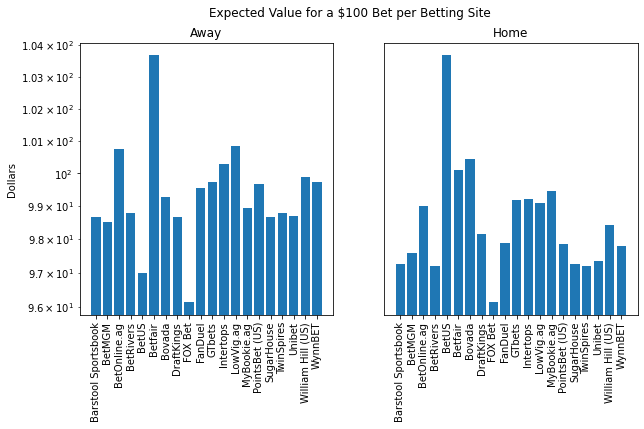

In [91]:
# Plot our expected values
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
fig.suptitle('Expected Value for a $100 Bet per Betting Site')

# Make subplots to show both home and away bets
plt.subplot(1, 2, 1)
plt.bar(range(len(away_sites)), away_totals, tick_label = away_sites)
plt.xticks(rotation=90)
# We are using a log scale so we can more clearly see the difference
plt.yscale("log",base=10)
plt.title('Away')
plt.ylabel('Dollars')
  
plt.subplot(1, 2, 2)
plt.bar(range(len(home_sites)),home_totals, tick_label = home_sites)
plt.xticks(rotation=90)
plt.yscale("log",base=2)
plt.title('Home')


plt.show()

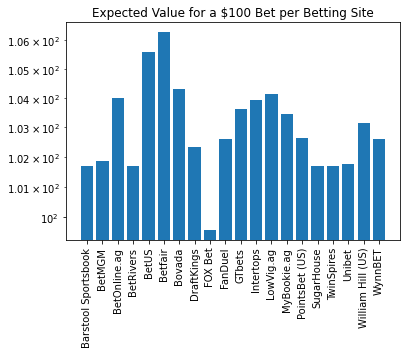

In [94]:
# Now we want to see expected value overall for a $100 Bet
overall_totals = list()
for (item1, item2) in zip(away_totals, home_totals):
    overall_totals.append((item1+item2)/2)
    
plt.bar(range(len(away_sites)), overall_totals, tick_label = away_sites)
plt.xticks(rotation=90)
plt.yscale("log",base=10)
plt.title('Expected Value for a $100 Bet per Betting Site')
plt.show()

In [87]:
# Get a list of all the unique games in our dataframe
games = list(h2h_combined['Game_ID'].unique())

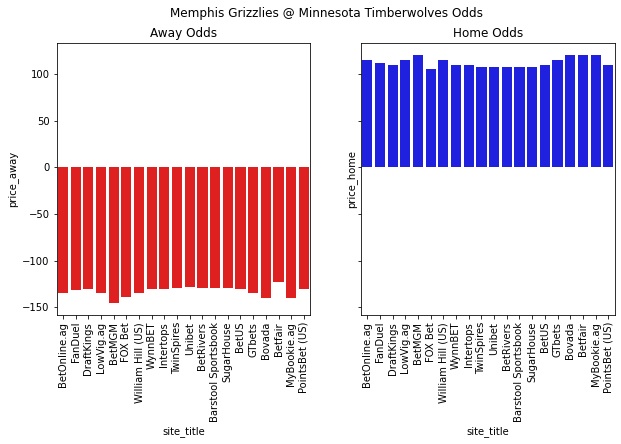

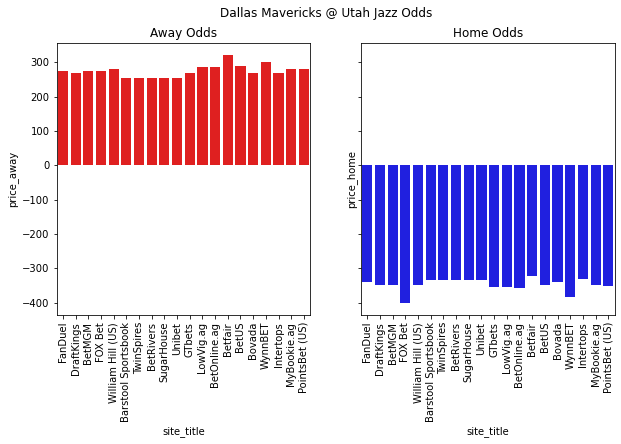

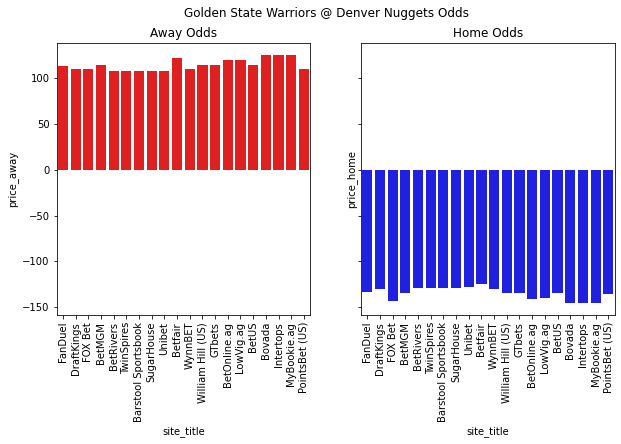

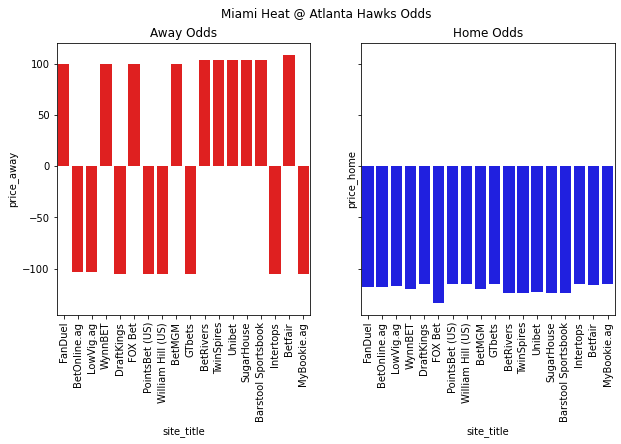

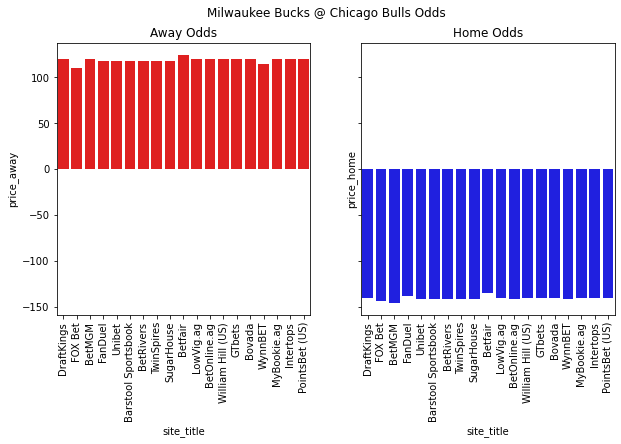

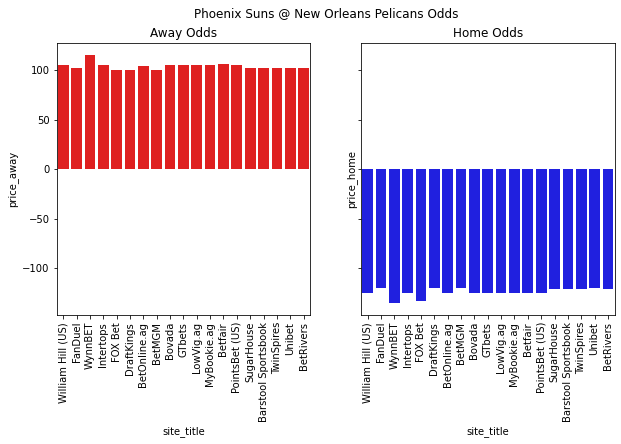

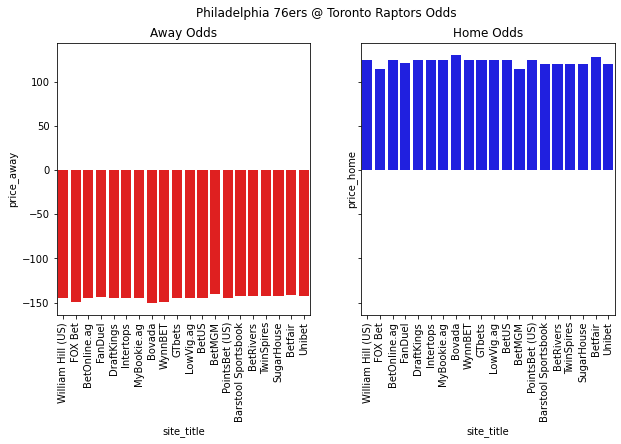

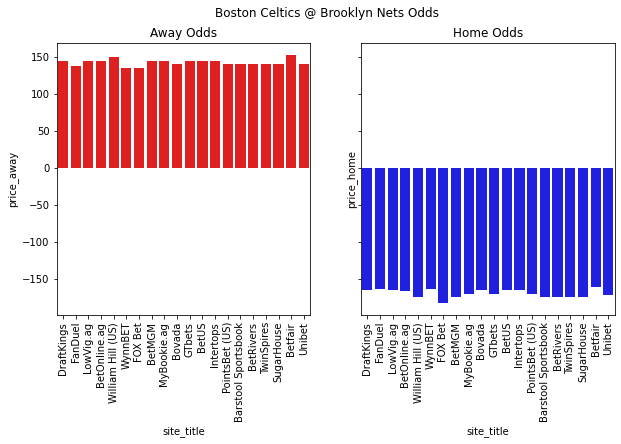

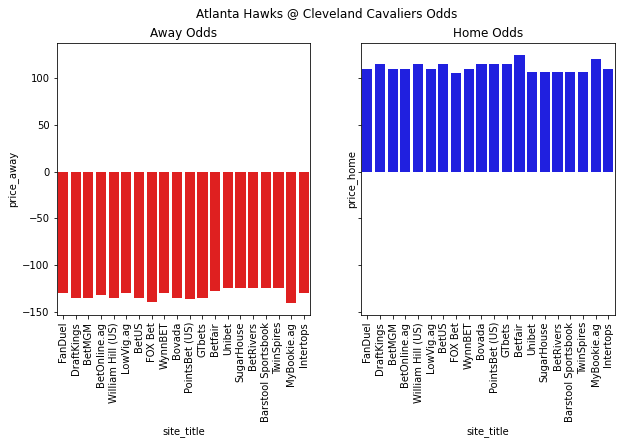

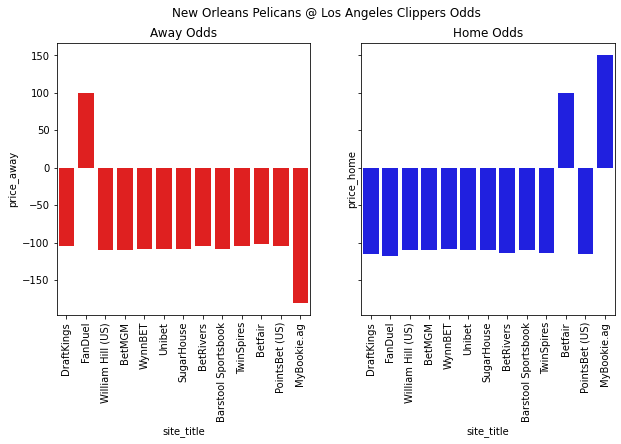

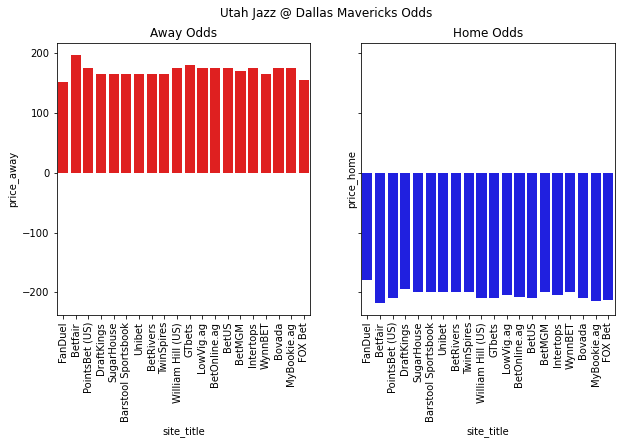

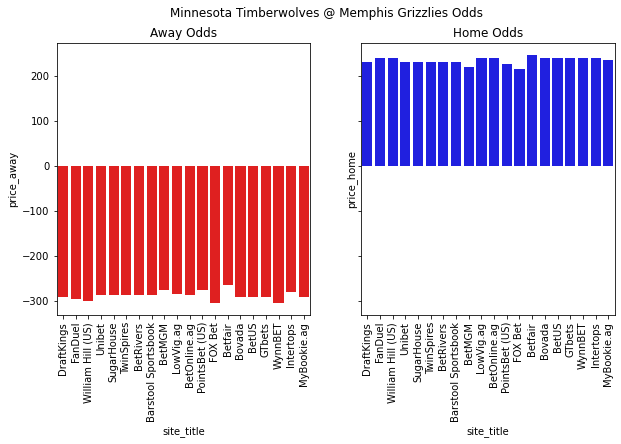

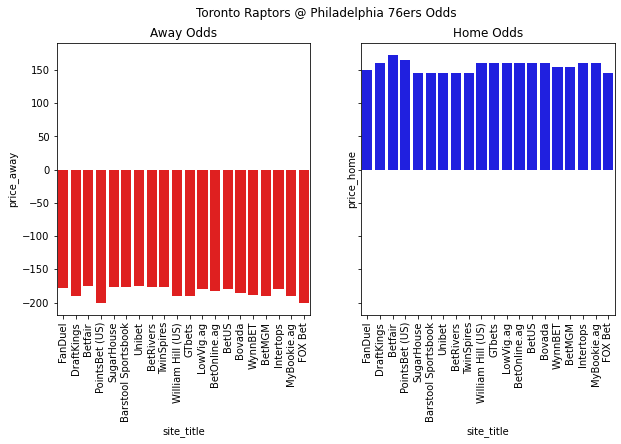

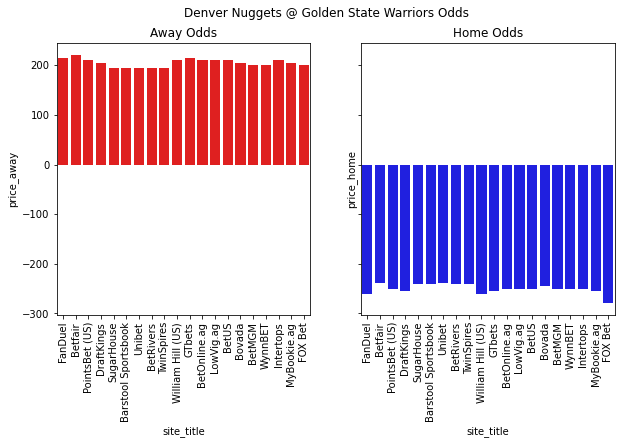

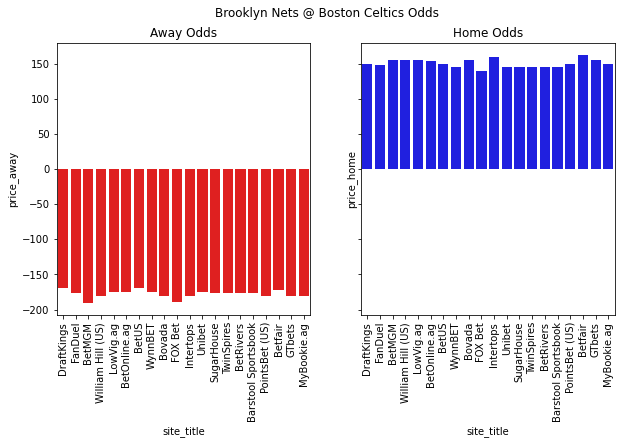

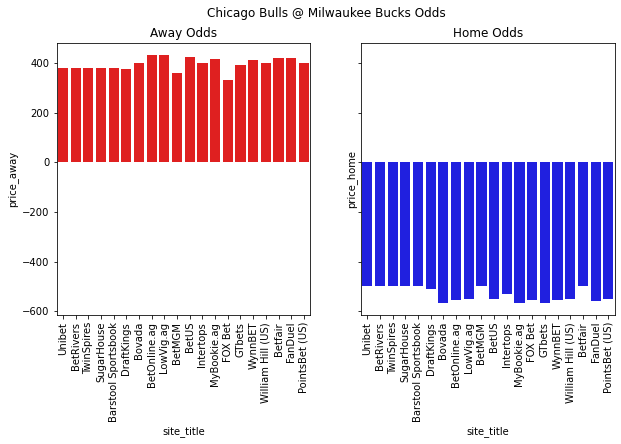

In [34]:
#Import some additional packages
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

for game in games:
    data = h2h_combined[h2h_combined['Game_ID'] == game]
    home_team_Str = data['home_team'].iloc[0]
    away_team_Str = data['away_team'].iloc[0]
    
    #plt.subplot(4, 4, index)
    # Building a vizualization best for the odds of each betting site per game
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    fig.suptitle(f'{away_team_Str} @ {home_team_Str} Odds')
    
    sns.barplot(ax = axes[0], x="site_title",y = "price_away",data= data, color = 'red')
    axes[0].set_title('Away Odds')
    axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation = 90)
    
    sns.barplot(ax = axes[1], x="site_title",y="price_home", data=data, color='blue')
    plt.xticks(rotation=90)
    axes[1].set_title('Home Odds')
    
    plt.show()

In [101]:
h2h_combined

,Unnamed: 0,Game_ID,away_team,bet_format,home_team,price_away,price_home,site_title,away_wins,home_wins,away_exp_value ($100 bet),home_exp_value ($100 bet),winner_away
0,0,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,BetOnline.ag,46,44,94.870370,97.825000,True
2,2,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-132.0,112.0,FanDuel,46,44,95.787879,96.460000,True
4,4,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-130.0,110.0,DraftKings,46,44,96.423077,95.550000,True
6,6,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-135.0,115.0,LowVig.ag,46,44,94.870370,97.825000,True
8,8,2647c9e2bee2448aff8cd9f719e18227,Memphis Grizzlies,h2h,Minnesota Timberwolves,-145.0,120.0,BetMGM,46,44,92.086207,100.100000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,299,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,410.0,-556.0,WynnBET,52,48,140.250000,97.338129,False
301,301,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,400.0,-550.0,William Hill (US),52,48,137.500000,97.500000,False
303,303,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-500.0,Betfair,52,48,143.000000,99.000000,False
305,305,4aa919d9d10d73ab59f145c35afbf782,Chicago Bulls,h2h,Milwaukee Bucks,420.0,-560.0,FanDuel,52,48,143.000000,97.232143,False


## Machine Learning: K-Means Clustering

For our machine learning aspect of our project, we wanted to use K-Means Clustering to find similarities between groups of bets by clustering based off of the odds for a team with win, the probability of each team to win, and the amount of wins in the regular season to see if there is a trend amongst the bets that hit.

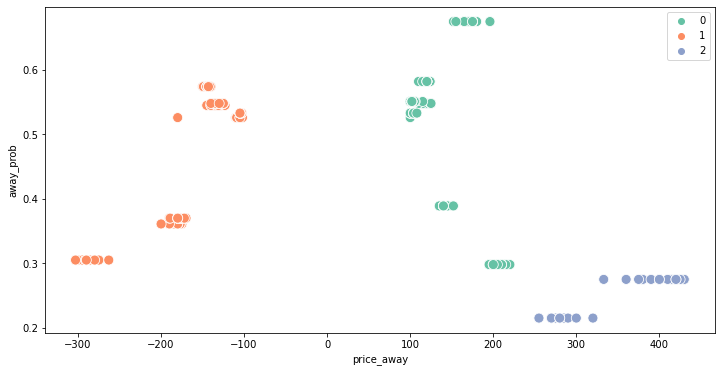

In [126]:
from sklearn.cluster import KMeans
n_clusters = 3
kmeans = KMeans(n_clusters = n_clusters)

x_feat_list = ['price_away', 'away_wins', 'away_prob']
x = h2h_combined.loc[:, x_feat_list].values

kmeans.fit(x)
y=kmeans.predict(x)

sns.scatterplot(data=h2h_combined, x='price_away', y='away_prob', s=100, hue=y, palette='Set2')
plt.gcf().set_size_inches(12, 6)